# NMPC with the solve time on the IDAES CSTR

`drto.nonideal_nmpc` runs the closed loop of the
[ideal NMPC page](cstr_ideal_nmpc.ipynb) with the controller's
computation inside it. The ideal loop implements each move at the
instant it measures. Here the move takes effect one delay later, and the
previous move holds until then, so a solve that takes a noticeable part
of the sampling interval shows up in the trajectory. This page runs the
same model under the ideal loop, under a prescribed delay, and under the
solve times the solver reports.

## The loop

Write $x_k$ for the state measured at sample $k$, $u_k$ for the move
solved there, $w_k$ for the disturbance values over the interval, $h$
for the sampling interval, and $d_k$ for the delay. Each step does the
following.

1. Solve the horizon problem at $x_k$, giving $u_k$, and take $d_k$.
2. Simulate the process for $d_k$ under the previous move $u_{k-1}$.
3. Simulate it for the remaining $h - d_k$ under $u_k$, reaching
   $x_{k+1}$.

The first step's previous move is the declared control targets, the
inputs the process held before the loop. A delay of zero runs the
interval in one piece under $u_k$, which is the ideal loop. A delay at
or past $h$ runs it in one piece under $u_{k-1}$, and $u_k$ takes effect
at the next boundary.

The process is discretized once, at the sampling interval, and each
piece is simulated by setting a duration Param that scales the declared
dynamics, so over an element of the declared length the state advances
as it would over the piece.

## The declared model and its setpoint

The saponification CSTR of `models/idaes_cstr.py`, with its targets read
off a steady simulation at zero duty and nominal feed, as on the ideal
NMPC page. Its declared states carry `mol` and their derivatives
`mol/s`, so the declared time units read as seconds and the solver's
reported seconds convert without a further statement.

In [1]:
import pyomo.environ as pyo

import drto
from models.idaes_cstr import DC_START, F_IN, VOLUME, build


def build_cstr_at_setpoint(N=10, h=1, disturbance=False):
    """The declared model with its targets read off a steady simulation.

    A builder in feature 006's sense: it returns the declared,
    undiscretized model, and its first two parameters are N and h with
    defaults.
    """
    m = build(N=N, h=h, disturbance=disturbance)
    ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
        m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                     m.fs.cstr.inlet.flow_vol.name: F_IN})
    drto.initialize_steady_state(ss)
    drto.scaled_solve(ss)
    cvs = ss.fs.cstr.control_volume
    for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
                   ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
        ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
    for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
                   ("SodiumAcetate", -1), ("Ethanol", -1)):
        m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
    for k in m.eng_ss:
        m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
    return m


def largest_gaps(a, b):
    """Print each state's and move's largest gap between two histories."""
    for kind, x, y in (("state", a.states, b.states), ("move", a.moves, b.moves)):
        for name in x:
            gap = max(abs(p - q) for p, q in zip(x[name], y[name]))
            span = max(y[name]) - min(y[name])
            print(f"{kind:5s} {name:34s} largest gap {gap:9.3g}   range {span:9.3g}")

## A prescribed delay

Ten samples of one second each, from the hot start. The ideal loop is
the baseline, and the second run holds each move for the first 0.3 s of
its interval. Everything else is the same call, so the gaps below are
what the delay costs.

In [2]:
options = dict(
    steps=10,
    dynamic_optimization={"infinite_horizon": True},
    initialize={"profile": "exponential", "time_constant": 0.3},
    scale={"J": 1e7, "W": 1e6},
)

ideal = drto.ideal_nmpc(build_cstr_at_setpoint, **options)
delayed = drto.nonideal_nmpc(build_cstr_at_setpoint, delay=0.3, **options)
print("effect times:", [round(t, 2) for t in delayed.effect_times])
print()
largest_gaps(delayed, ideal)

effect times: [0.3, 1.3, 2.3, 3.3, 4.3, 5.3, 6.3, 7.3, 8.3, 9.3]

state material_holdup_Liq_NaOH           largest gap      2.21   range        20
state material_holdup_Liq_EthylAcetate   largest gap      2.21   range        20
state material_holdup_Liq_SodiumAcetate  largest gap      2.21   range        20
state material_holdup_Liq_Ethanol        largest gap      2.21   range        20
state energy_holdup[Liq]                 largest gap  2.99e+06   range  5.82e+07
move  heat                               largest gap   3.9e+05   range  3.94e+06
move  _flow_vol_inlet_ref                largest gap    0.0405   range     0.797


## The delay the solver reports

`delay="solver"` takes each solve's reported wall time, in seconds, and
converts it into the declared time units. On this flowsheet and this
machine a horizon solve takes about a third of the one second interval,
so each move takes effect about a third of the way in and no step
clamps. A solve that reached the interval would clamp, holding the
previous move throughout and taking effect at the next boundary.

In [3]:
measured = drto.nonideal_nmpc(build_cstr_at_setpoint, delay="solver", **options)
print("delays, s:  ", [round(d, 2) for d in measured.delays])
print("clamped at: ", measured.clamped or "no step")
print()
largest_gaps(measured, ideal)

delays, s:   [0.37, 0.29, 0.31, 0.33, 0.25, 0.3, 0.28, 0.26, 0.29, 0.32]
clamped at:  no step

state material_holdup_Liq_NaOH           largest gap      2.36   range        20
state material_holdup_Liq_EthylAcetate   largest gap      2.36   range        20
state material_holdup_Liq_SodiumAcetate  largest gap      2.36   range        20
state material_holdup_Liq_Ethanol        largest gap      2.36   range        20
state energy_holdup[Liq]                 largest gap  3.81e+06   range  5.82e+07
move  heat                               largest gap  4.91e+05   range  3.94e+06
move  _flow_vol_inlet_ref                largest gap     0.053   range     0.797


## The trajectories

The states draw at the sample instants, as they do for the ideal loop.
The moves draw as the staircase they physically are, stepping at the
instant each one took effect rather than at the sample that solved it.

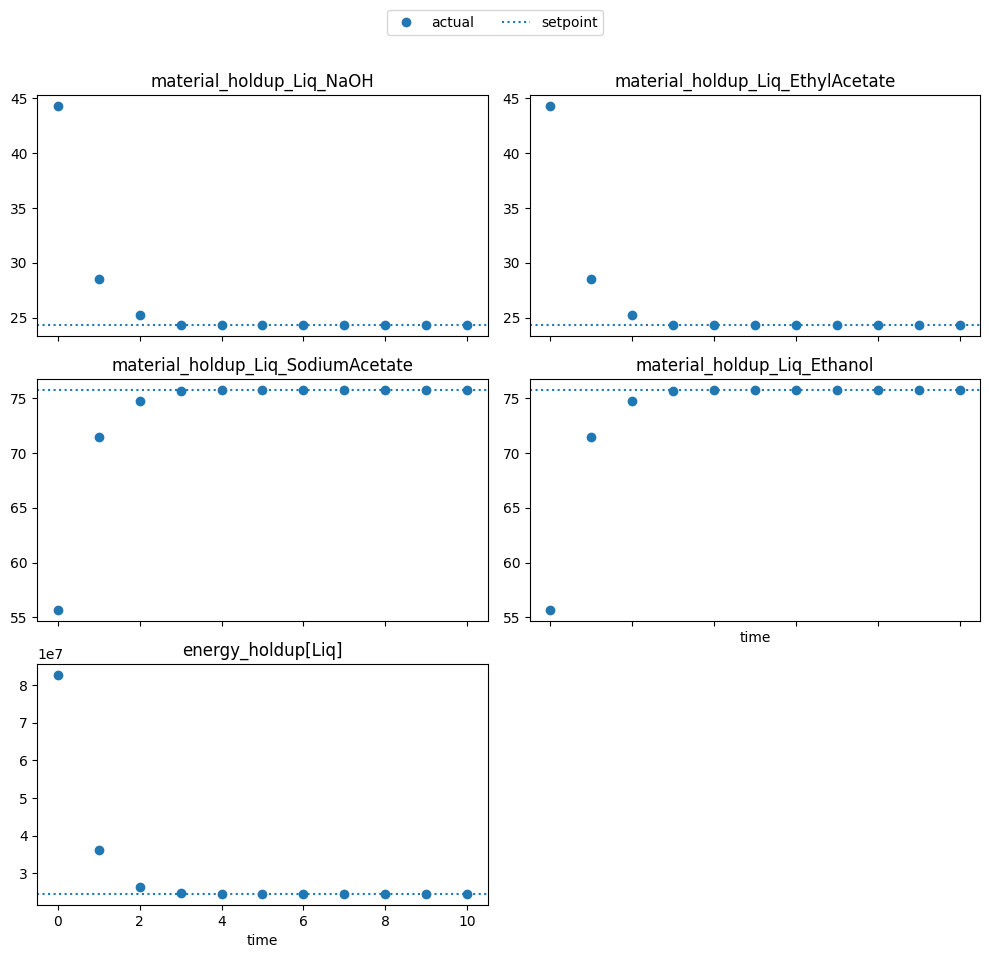

In [4]:
axes = drto.plot_states(measured)

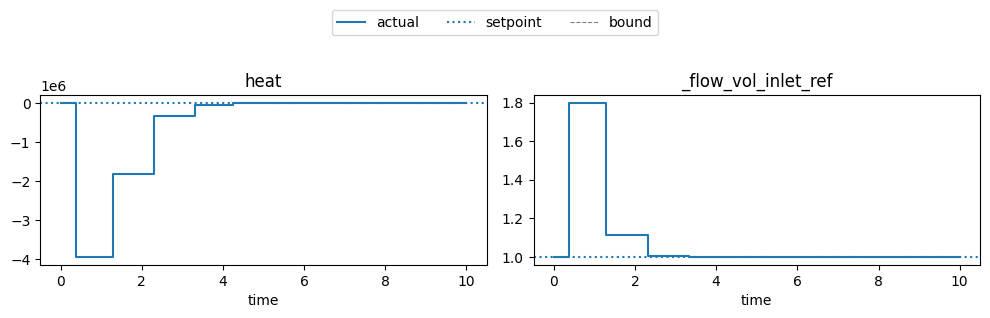

In [5]:
axes = drto.plot_controls(measured)